We worked on 2D polynomial Regression in the last notebook, lets go 3 Dimesionalllll

# 3D Polynomial Regression

In [34]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
import plotly.express as px
from sklearn.preprocessing import PolynomialFeatures

Lets make some 3D data first

In [13]:
x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)

This polynomial looks something like this : z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

Lets plot it in 3D

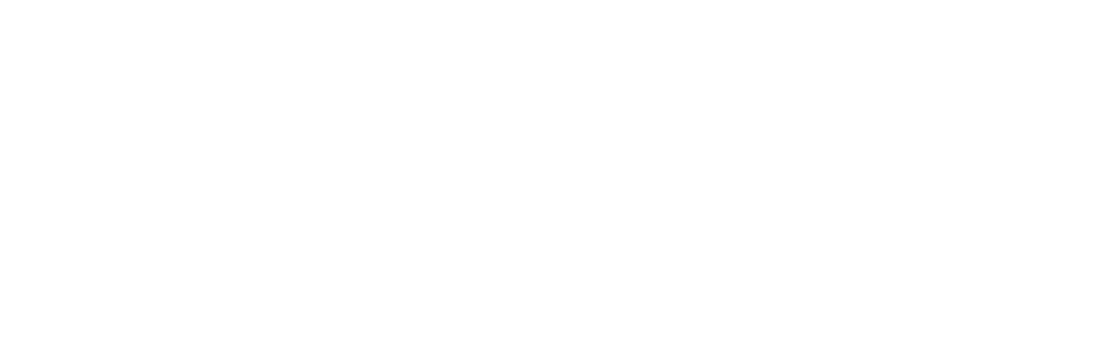

In [14]:
fig = px.scatter_3d(x=x.ravel(), y = y.ravel(), z = z.ravel())
fig.show()

Lets fit normal Linear Regression to check what are the results.

In [29]:
lr = LinearRegression()

lr.fit(np.array([x,y]).reshape(100,2), z)

# Here we are preparing Grid Points for prediction
x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)

# np.meshgrid takes two 1D arrays (vectors) that represent the coordinates along the x-axis and y-axis and turns them into two 2D grids.
#These grids represent all combinations of x and y points in a grid layout.
# We are doing this to test our lr model on the range of the all the points in the plane
xGrid, yGrid = np.meshgrid(x_input, y_input)

final = np.vstack((xGrid.ravel().reshape(1,100), yGrid.ravel().reshape(1,100))).T
# The above step will reshape 10x10 matrices to row vector, stack them on each other, and then transpose them finally to the shape (100x2)

z_final = lr.predict(final).reshape(10,10)
# we are predicting z_final and reshaping it into the 10x10 matrix again similar to the 10x10 of the xGrid and yGrid

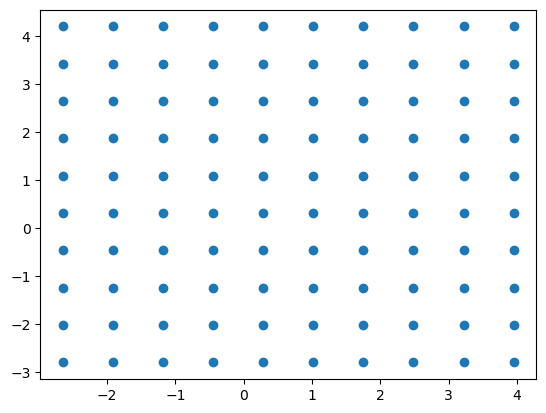

In [30]:
plt.scatter(xGrid, yGrid)

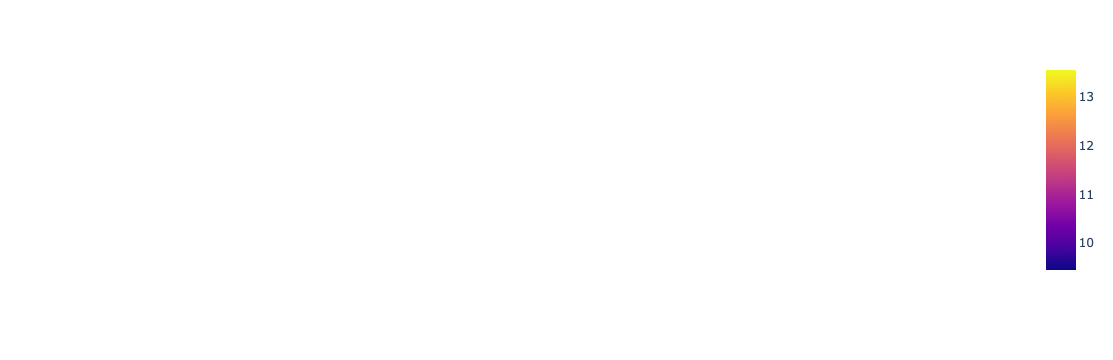

In [32]:
import plotly.graph_objects as go

fig = px.scatter_3d(x = x.ravel(), y = y.ravel(), z = z.ravel())
fig.add_trace(go.Surface(x = x_input, y = y_input, z = z_final))
fig.show()

See this is the linear prediction for our polynomial/Non linear data, not at all satisfying

In [35]:
X_poly = np.array([x,y]).reshape(100, 2)
X_poly.shape

(100, 2)

Now lets find out the polynomial features of the data to do polynomial regression 

In [43]:
poly = PolynomialFeatures(degree=2)
X_poly_trans = poly.fit_transform(X_poly)

Lets see how many input and output features are made in the process

In [44]:
print("Input features: ", poly.n_features_in_)
print("Output features: ", poly.n_output_features_)
print("Powers: \n", poly.powers_)

Input features:  2
Output features:  6
Powers: 
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


The above powers indicate the different kind of terms like the x^0 and y^0 [0,0], similarly for all others, note that the degree of the polynomial is 2, so the power neveer exceeds 2.

In [45]:
X_poly_trans.shape

(100, 6)

In [46]:
lr = LinearRegression()
lr.fit(X_poly_trans, z)

LinearRegression()

In [47]:
z_poly = poly.transform(final)
z_final = lr.predict(X_poly_trans).reshape(10,10)

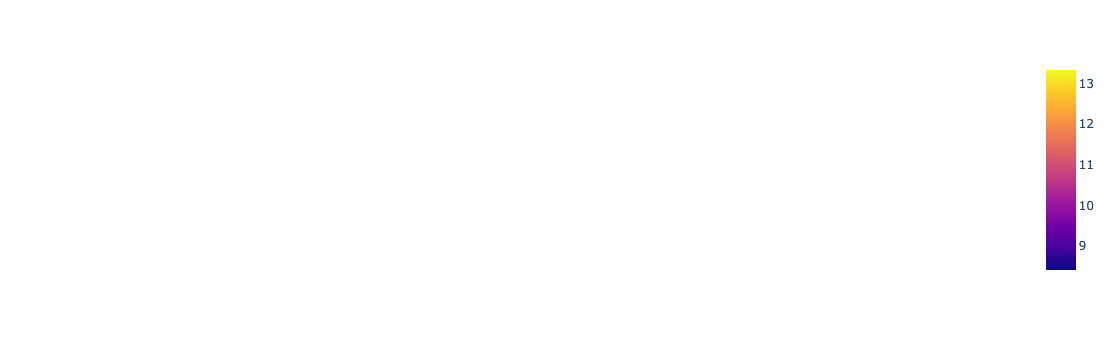

In [49]:
fig = px.scatter_3d(x = x.ravel(), y = y.ravel(), z = z.ravel())
fig.add_trace(go.Surface(x = x_input, y = y_input, z = z_final))
fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))
fig.show()